**Test Paper generation via Crew AI and PEFT Model**

In this approach, Crew AI leverages multiple agents to provide enriched context and a Parameter-Efficient Fine-Tuning (PEFT) model trained specifically to generate relevant questions from the given context. Together, they create a dynamic question paper generation system tailored to a student's selected topic. Crew AI agents gather, refine, and structure content, ensuring comprehensive coverage of the topic, while the PEFT model transforms the curated context into diverse and well-formulated questions. This collaboration produces a seamless test paper generation process, offering students customized assessments that align with their learning objectives.
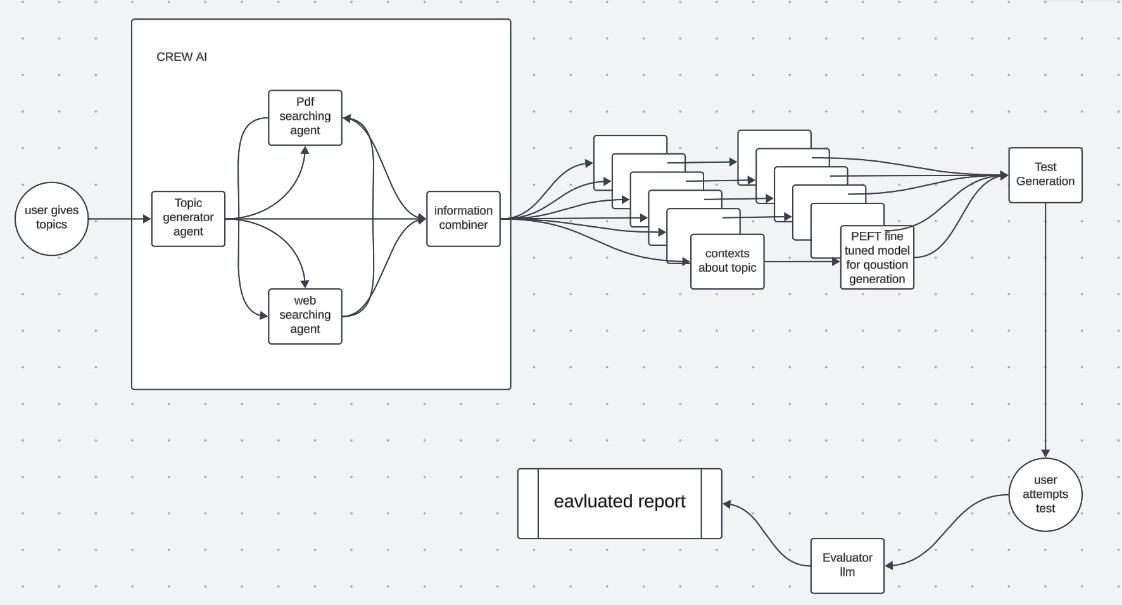

## STEP 1 : Install Dependencies

In [3]:
!pip uninstall -y crewai crewai-tools

!pip install \
crewai==0.121.1 \
crewai-tools==0.45.0 \
langchain-community \
langchain-groq \
langchain-openai \
langchain-huggingface \
langchain-google-community \
langchain-google-genai \
langchain-text-splitters \
sentence-transformers \
pypdf \
duckduckgo-search \
peft \
wikipedia

Found existing installation: crewai 0.121.1
Uninstalling crewai-0.121.1:
  Successfully uninstalled crewai-0.121.1
Found existing installation: crewai-tools 0.45.0
Uninstalling crewai-tools-0.45.0:
  Successfully uninstalled crewai-tools-0.45.0
  Using cached crewai-0.121.1-py3-none-any.whl.metadata (35 kB)
  Using cached crewai_tools-0.45.0-py3-none-any.whl.metadata (10 kB)
Using cached crewai-0.121.1-py3-none-any.whl (320 kB)
Using cached crewai_tools-0.45.0-py3-none-any.whl (602 kB)


In [4]:
!pip install litellm

## STEP 2 : Project Setup

this section contains inital project setup includeing

*   configuring groq
*   importing moudles
*   configurong llama3 as base model



In [5]:
import os

from google.colab import userdata

from langchain_openai import ChatOpenAI
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS

from crewai import Agent, Task, Crew
from crewai.process import Process
from crewai.tools import tool

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    pipeline
)

from peft import (
    PeftModel,
    PeftConfig
)

In [6]:
os.environ['GROQ_API_KEY'] = userdata.get('GROQ_API_KEY')

In [7]:
from crewai import LLM

llm = LLM(
    model="groq/llama-3.3-70b-versatile",
    api_key=os.environ["GROQ_API_KEY"],
    temperature=0.1
)

## STEP 3 : Setting up a LLM tools

this section consists configuration of 2 tools maily


*   we are using in built RAG tool provided by the crew ai
*   making custom WEB search tool by annotation


In [8]:
# Load the PDF file that serves as the knowledge base or context
loader = PyPDFLoader(
    "/content/context.pdf"
)

# Read the contents of the PDF and convert them into Document objects
documents = loader.load()

# Create a text splitter to divide the PDF into smaller overlapping chunks
# chunk_size determines the maximum size of each chunk
# chunk_overlap ensures continuity between consecutive chunks
splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200
)

# Split the loaded documents into smaller chunks
# These chunks will later be converted into embeddings and stored in the vector database
chunks = splitter.split_documents(documents)

In [9]:
pip install faiss-gpu

In [10]:
# Initialize the embedding model used to convert text chunks into vector representations
embeddings = HuggingFaceEmbeddings(
    model_name="BAAI/bge-small-en-v1.5"
)

# Create a FAISS vector database from the document chunks and their embeddings
# This vector store enables efficient semantic similarity search
vector_store = FAISS.from_documents(
    chunks,
    embeddings
)

# Create a retriever from the vector store
# k specifies the number of most relevant chunks to retrieve
retriever = vector_store.as_retriever(
    search_kwargs={"k": 3}
)

In [11]:
# Create a custom tool that performs semantic search over the PDF knowledge base
@tool
def rag_tool(query: str) -> str:
    """
    Search the PDF knowledge base and return relevant context.
    """

    # Retrieve the most relevant chunks corresponding to the query
    docs = retriever.invoke(query)

    # Combine the retrieved chunks into a single context string
    context = "\n\n".join(
        doc.page_content
        for doc in docs
    )

    return context

In [12]:
print(rag_tool.run("What are the necessary conditions for deadlock?"))

Using Tool: rag_tool
Silberschatz, Galvin and Gagne ©2009Operating System Concepts – 8th Edition
Chapter 7:  Deadlocks

7.6 Silberschatz, Galvin and Gagne ©2009Operating System Concepts – 8th Edition
The Deadlock Problem
● A set of blocked processes each holding a resource and waiting to 
acquire a resource held by another process in the set
● Example 
● System has 2 disk drives
● P1 and P2 each hold one disk drive and each needs another one
● Example 
● semaphores A and B, initialized to 1 P0   P1
     wait (A); wait(B) wait (B); wait(A)

7.3 Silberschatz, Galvin and Gagne ©2009Operating System Concepts – 8th Edition
Chapter Objectives
● To develop a description of deadlocks, which prevent sets of 
concurrent processes from completing their tasks
● To present a number of diﬀerent methods for preventing or avoiding 
deadlocks in a computer system


In [13]:

from langchain_community.retrievers import WikipediaRetriever

@tool('web_search_tool')
def web_search_tool(question: str) -> str:
    """
    Tool for conducting web searches on wikipedia and retrieving summarized content.

    **Inputs**:
      - `question` (str): A **plain string** representing a concise search query
        (e.g., "latest AI trends", "Python web scraping").
      - **Note**: `question` should be a **string only**, not a dictionary or complex object.

    **Input Type**:
      - `question` is expected to be a **string**.

    """
    retriever = WikipediaRetriever()
    docs = retriever.invoke(question)
    info = ""
    for word in docs[0].page_content.split(' ')[0:600]:
        info += word + " "
    return info

Now i am creating agents

In [14]:
# Topic Provider Agent
topic_provider = Agent(
    role="Instructor",
    goal=(
        "Identify important subjects and subtopics necessary "
        "for a complete understanding of the given topic."
    ),
    backstory=(
        "A knowledgeable instructor providing a structured outline "
        "of essential topics and subtopics for effective study."
    ),
    verbose=False,
    llm=llm,
    allow_delegation=False
)

In [15]:
# PDF Content Extractor Agent
pdf_content_extractor = Agent(
    role="PDF Content Extractor",
    goal=(
        "Extract relevant information from the PDF and provide "
        "detailed explanations for the identified topics."
    ),
    backstory=(
        "An instructor specialized in extracting comprehensive "
        "knowledge directly from PDF documents."
    ),
    verbose=False,
    llm=llm,
    allow_delegation=False
)

In [16]:
# Web Content Extractor Agent
web_content_extractor = Agent(
    role="Web Content Extractor",
    goal=(
        "Search the web for topics provided by the topic provider. "
        "One search is enough. Return useful content related to the topic."
    ),
    backstory=(
        "An instructor collecting extensive web-based knowledge "
        "to fill gaps in PDF content."
    ),
    verbose=False,
    llm=llm,
    allow_delegation=False
)

In [17]:
# Information Combiner Agent
info_combiner = Agent(
    role="Information Combiner",
    goal=(
        "Combine information gathered from PDF and web sources into "
        "a single cohesive study guide. Organize and synthesize the "
        "information and provide comprehensive theoretical explanations."
    ),
    backstory=(
        "A tutor combining insights from multiple sources to create "
        "a well-rounded and thorough study guide."
    ),
    verbose=False,
    llm=llm,
    allow_delegation=False
)

In [18]:
# Topic Summary Task
topic_summary_task = Task(
    description="""
    Analyze the topic {input} and identify the important
    subjects and subtopics required for a complete understanding.
    """,
    agent=topic_provider,
    expected_output="""
    A list of important topics and subtopics.
    """
)


# PDF Search Task
pdf_search_task = Task(
    description="""
    Using the topics identified previously, search the PDF and
    extract the relevant information.
    """,
    agent=pdf_content_extractor,
    tools=[rag_tool],
    context=[topic_summary_task],
    expected_output="""
    Relevant information extracted from the PDF.
    """
)


# Web Search Task
web_search_task = Task(
    description="""
    Search the web and extract additional useful information
    related to the identified topics.
    """,
    agent=web_content_extractor,
    tools=[web_search_tool],
    context=[topic_summary_task],
    expected_output="""
    Relevant information gathered from the web.
    """
)


# Information Combination Task
info_combination_task = Task(
    description="""
    Combine the information obtained from the PDF and web sources.

    Provide exactly 10 points.

    Each point should represent a key subtopic and contain a
    detailed explanation.

    Do not mention sources.
    """,
    agent=info_combiner,
    context=[
        pdf_search_task,
        web_search_task
    ],
    expected_output="""
    Ten detailed points explaining the topic.
    """
)

In [19]:
crew = Crew(
    agents=[
        topic_provider,
        pdf_content_extractor,
        web_content_extractor,
        info_combiner
    ],
    tasks=[
        topic_summary_task,
        pdf_search_task,
        web_search_task,
        info_combination_task
    ],
    process=Process.sequential,
    verbose=False
)

In [20]:
simple_agent = Agent(
    role="Teacher",
    goal="Explain operating systems",
    backstory="Expert teacher",
    llm=llm,
    verbose=False,
    allow_delegation=False
)

simple_task = Task(
    description="Explain deadlocks.",
    expected_output="A concise explanation of deadlocks in operating systems.",
    agent=simple_agent
)

simple_crew = Crew(
    agents=[simple_agent],
    tasks=[simple_task],
    verbose=False
)

result = simple_crew.kickoff()

print(result)

Deadlocks in operating systems refer to a situation where two or more processes are unable to complete their execution because each is waiting for the other to release a resource. This results in a permanent standoff, and none of the processes can proceed. Deadlocks occur when the following four necessary conditions, known as Coffman conditions, are met simultaneously:

1. **Mutual Exclusion**: Two or more processes must be competing for a common resource that cannot be used simultaneously by more than one process. This resource is said to be non-shareable.

2. **Hold and Wait**: One process must be holding a resource and waiting for another resource, which is held by some other process. This means a process has gained access to a resource but is waiting for an additional resource to complete its task.

3. **No Preemption**: The operating system must not force a process to release a resource it holds. The process should release the resource only when it is finished with it. If the oper

In [21]:
result = crew.kickoff(
    inputs={
        "input": "Operating System Deadlocks"
    }
)

print(result)

1. **Introduction to Deadlocks**: Deadlocks are a common problem in concurrent computing where a group of entities cannot proceed because each waits for another member to take action. This situation can occur in multiprocessing systems, parallel computing, and distributed systems, often due to the use of software or hardware locks to arbitrate shared resources and implement process synchronization. Understanding deadlocks is crucial for designing and developing efficient and reliable systems.

2. **Conditions for Deadlock**: A deadlock situation can arise only if all of the following conditions occur simultaneously: mutual exclusion, hold and wait, no preemption, and circular wait. These conditions, known as the Coffman conditions, are sufficient to produce a deadlock on single-instance resource systems but only indicate the possibility of deadlock on systems having multiple instances of resources. Understanding these conditions is essential for preventing or avoiding deadlocks.

3. **

In [22]:
import re

def convert_to_json(crew_result):
    pattern = r"\d+\.\s+\*\*(.*?)\*\*:\s*(.*?)(?=\n\d+\.\s+\*\*|\Z)"

    matches = re.findall(pattern, crew_result, re.DOTALL)

    result = []

    for title, context in matches:
        result.append(
            {
                "context_title": title.strip(),
                "context": context.strip()
            }
        )

    return result

In [23]:
out = convert_to_json(result.raw)

print(out[0]["context_title"])
print(out[0]["context"])

Introduction to Deadlocks
Deadlocks are a common problem in concurrent computing where a group of entities cannot proceed because each waits for another member to take action. This situation can occur in multiprocessing systems, parallel computing, and distributed systems, often due to the use of software or hardware locks to arbitrate shared resources and implement process synchronization. Understanding deadlocks is crucial for designing and developing efficient and reliable systems.


## STEP 5 : PEFT MODEL configuration

I have created a peft model fintuned for the perticular down stream task of converting context into question

the model was orignally trained on kagle note book , refrene to the model and training can be found here :

In this section, a custom PEFT model is used to convert context into examination questions. Instead of using a general-purpose language model directly, a LoRA fine-tuned version of Google's Gemma-2-2B-IT model is employed for this specific downstream task. This allows the system to generate concise and relevant questions while requiring significantly fewer trainable parameters.

The model was trained using Parameter-Efficient Fine-Tuning (PEFT) with LoRA (Low-Rank Adaptation). A custom dataset containing approximately 1000 context-question pairs was prepared.

Hugging face login : here we logged ourself in to hugging face the reason being acessing gemma model from hugging face requires hugging face acess

Create or Log into Your Hugging Face Account:

* Go to Hugging Face's website : http://huggingface.co/  and log in to your account. If you don’t have one, click on "Sign Up" to create an account.
Access Your Account Settings:

* Once logged in, click on your profile picture in the upper-right corner of the page.
Select Settings from the dropdown menu.
Navigate to the "Access Tokens" Section:

* In the settings menu, locate and click on Access Tokens on the left sidebar.
Generate a New API Key:

* Click on the New token button to create a new API key.
Choose a name for the token and assign it the necessary permissions based on your requirements (usually, Read permission is sufficient for API usage).
Save and Copy the API Key:

* After creating the token, click Create. The API key will be displayed; make sure to copy and save it securely, as you'll need it to authenticate with the Hugging Face API.

In [24]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [25]:
!pip uninstall -y torchao
!pip install torchao>=0.16.0

Found existing installation: torchao 0.17.0
Uninstalling torchao-0.17.0:
  Successfully uninstalled torchao-0.17.0


In [26]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel

model_name = "google/gemma-2-2b-it"

tokenizer = AutoTokenizer.from_pretrained(model_name)

base_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16
)

peft_model = PeftModel.from_pretrained(
    base_model,
    "/content/drive/MyDrive/question_lora"
)

model = peft_model.merge_and_unload()

model = model.cuda()

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [27]:
def create_prompt_for_inference(context):

    prompt = f"""
<start_of_turn>user
Generate one examination question from the following context.

Context:
{context}
<end_of_turn>

<start_of_turn>model
"""

    return prompt

In [30]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [31]:
def generate_question(context):

    prompt = create_prompt_for_inference(context)

    inputs = tokenizer(
        prompt,
        return_tensors="pt"
    ).to(device)

    outputs = model.generate(
        **inputs,
        max_new_tokens=64,
        do_sample=False
    )

    generated = tokenizer.decode(
        outputs[0],
        skip_special_tokens=False
    )

    question = (
        generated
        .split("<start_of_turn>model")[-1]
        .split("<end_of_turn>")[0]
        .strip()
    )

    return question

In [32]:
from tqdm import tqdm

def create_test_paper(out):

    test = """

The following is an AI-generated test based on your provided PDF and web content.

TEST TIME : 30 mins
TOTAL QUESTIONS : 10
TOTAL MARKS : 100

NOTE : All questions are compulsory.

ALL THE BEST!

"""

    for i, item in enumerate(
            tqdm(out, desc="Generating Test Paper"),
            start=1):

        context = item["context"]

        question = generate_question(context)

        test += f"""

Topic : {item['context_title']} (10 marks)

Q{i}. {question}

"""

    return test

In [35]:
out = convert_to_json(result.raw)

In [36]:
test_paper = create_test_paper(out)

print(test_paper)

Generating Test Paper: 100%|██████████| 10/10 [00:06<00:00,  1.66it/s]



The following is an AI-generated test based on your provided PDF and web content.

TEST TIME : 30 mins
TOTAL QUESTIONS : 10
TOTAL MARKS : 100

NOTE : All questions are compulsory.

ALL THE BEST!



Topic : Introduction to Deadlocks (10 marks)

Q1. What are the characteristics of deadlocks?



Topic : Conditions for Deadlock (10 marks)

Q2. What are the Coffman conditions?



Topic : Types of Deadlocks (10 marks)

Q3. What is a resource deadlock?



Topic : Deadlock Prevention (10 marks)

Q4. What is deadlock prevention?



Topic : Deadlock Avoidance (10 marks)

Q5. What is deadlock avoidance?



Topic : Deadlock Detection (10 marks)

Q6. What is deadlock detection?



Topic : Deadlock Recovery (10 marks)

Q7. What is resource preemption in deadlock recovery?



Topic : Real-World Examples of Deadlocks (10 marks)

Q8. What are the causes of deadlocks?



Topic : Deadlock Handling in Operating Systems (10 marks)

Q9. What are the advantages of using deadlock detection and recovery tech

In [37]:
answer_sheet = """

Q1. What are the characteristics of deadlocks?

Ans:
Deadlocks occur when a set of processes are permanently blocked because each process is waiting for a resource held by another process. They involve mutual dependence and prevent processes from making progress.

Q2. What are the Coffman conditions?

Ans:
The four Coffman conditions are:
1. Mutual Exclusion
2. Hold and Wait
3. No Preemption
4. Circular Wait

Q3. What is a resource deadlock?

Ans:
A resource deadlock occurs when multiple processes compete for limited resources and each process waits indefinitely for resources held by other processes.

Q4. What is deadlock prevention?

Ans:
Deadlock prevention is a technique that ensures at least one of the necessary conditions for deadlock never occurs, thereby preventing the system from entering a deadlock state.

Q5. What is deadlock avoidance?

Ans:
Deadlock avoidance is a strategy that dynamically examines resource allocation states and ensures the system remains in a safe state. Banker's algorithm is a common deadlock avoidance algorithm.

Q6. What is deadlock detection?

Ans:
Deadlock detection is the process of identifying whether a deadlock has occurred in the system by using algorithms such as wait-for graphs or resource allocation graphs.

Q7. What is resource preemption in deadlock recovery?

Ans:
Resource preemption is a recovery technique in which resources are forcibly taken from some processes and allocated to others in order to break a deadlock.

Q8. What are the causes of deadlocks?

Ans:
Deadlocks are caused when the four Coffman conditions occur simultaneously and processes become involved in circular waiting for resources.

Q9. What are the advantages of using deadlock detection and recovery techniques?

Ans:
Deadlock detection and recovery allow better resource utilization because resources are allocated freely and deadlocks are handled only when they occur.

Q10. What is a deadlock in operating systems?

Ans:
A deadlock is a condition in which two or more processes are blocked indefinitely because each process is waiting for resources held by another process.

"""

In [40]:
evaluation_prompt = f"""
You are a strict examiner.

Question Paper:

{test_paper}

Student Answer Sheet:

{answer_sheet}

Evaluate each answer out of 10 based on accuracy,
relevance, completeness and clarity.

For every question provide:

- Marks awarded
- Explanation
- Mistakes
- Suggestions
- Understanding level

At the end provide:

- Total marks out of 100
- Percentage
- Strengths
- Weaknesses
- Overall remarks
"""

In [41]:
report = llm.call(evaluation_prompt)

print(report)

Here's the evaluation of each answer:

**Q1. What are the characteristics of deadlocks?**

* Marks awarded: 8/10
* Explanation: The answer provides a good definition of deadlocks, mentioning mutual dependence and permanent blocking of processes. However, it could be more detailed and include other characteristics such as resource unavailability.
* Mistakes: None significant
* Suggestions: Provide more details on the characteristics of deadlocks, such as resource unavailability and the inability of processes to make progress.
* Understanding level: Good (8/10)

**Q2. What are the Coffman conditions?**

* Marks awarded: 10/10
* Explanation: The answer correctly lists the four Coffman conditions: Mutual Exclusion, Hold and Wait, No Preemption, and Circular Wait.
* Mistakes: None
* Suggestions: None
* Understanding level: Excellent (10/10)

**Q3. What is a resource deadlock?**

* Marks awarded: 8/10
* Explanation: The answer provides a good definition of a resource deadlock, mentioning com

In [52]:
from langchain_google_genai import ChatGoogleGenerativeAI

class Teacher:

    def __init__(self):
        self.path = None
        self.answer_sheet = ""
        self.test_paper = ""

    def upload_pdf(self, path):
        self.path = path

    def ask(self, query):

        llm = ChatGoogleGenerativeAI(
            model="gemini-1.5-pro",
            temperature=0,
            max_tokens=None,
            timeout=None,
            max_retries=2
        )

        messages = [
            (
                "system",
                """
You are an experienced teacher.

Your job is to help students understand concepts clearly.

Guidelines:
- Explain concepts simply.
- Use examples wherever appropriate.
- Break complex ideas into smaller pieces.
- Encourage conceptual understanding rather than memorization.
- Be concise but sufficiently detailed.
- Always prioritize correctness and clarity.
"""
            ),
            (
                "human",
                query
            )
        ]

        ai_msg = llm.invoke(messages)

        return ai_msg.content

    def generate_test(self, topic):

        inputs = {
            "input": topic
        }

        result = crew.kickoff(inputs=inputs)

        out = convert_to_json(result.raw)

        self.test_paper = create_test_paper(out)

        return self.test_paper

    def upload_answer_sheet(self, path):

        with open(path, "r") as file:
            self.answer_sheet = file.read()
    def give_evaluation_report(self):

        llm = ChatGoogleGenerativeAI(
            model="gemini-1.5-pro",
            temperature=0,
            max_tokens=None,
            timeout=None,
            max_retries=2
        )

        evaluation_prompt = f"""
You are a senior university professor and an experienced examiner.

Question Paper:

{self.test_paper}

Student Answer Sheet:

{self.answer_sheet}

Evaluate the student's answers fairly but slightly strictly.

Evaluation Criteria:

1. Accuracy
2. Relevance
3. Completeness
4. Clarity

For EACH question provide:

- Question Number
- Marks Awarded (out of 10)
- Explanation for marks awarded
- Mistakes made by the student
- Missing concepts
- Suggestions for improvement
- Understanding Level
  (Excellent / Good / Average / Weak / Poor)

----------------------------------------------------

After evaluating all questions provide:

1. Total Marks Obtained (out of 100)

2. Percentage

3. Strengths

4. Weaknesses

5. Overall Performance
(Excellent / Very Good / Good / Average / Below Average / Poor)

6. Final Remarks

Be objective and slightly strict.

Do not award full marks unless the answer is exceptionally complete and technically accurate.

Present the report in a neat and structured format.
"""

        messages = [
            (
                "system",
                """
You are a senior professor with years of experience evaluating university examinations.

You are fair, objective and slightly strict.
Provide detailed feedback that helps students improve.
"""
            ),
            (
                "human",
                evaluation_prompt
            )
        ]

        ai_msg = llm.invoke(messages)

        return ai_msg.content


In [53]:
python_teacher = Teacher()